In [49]:
import pandas as pd

#Import data 
data = pd.read_csv("road_accident_dataset.csv")

In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132000 entries, 0 to 131999
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Country                      132000 non-null  object 
 1   Year                         132000 non-null  int64  
 2   Month                        132000 non-null  object 
 3   Day of Week                  132000 non-null  object 
 4   Time of Day                  132000 non-null  object 
 5   Urban/Rural                  132000 non-null  object 
 6   Road Type                    132000 non-null  object 
 7   Weather Conditions           132000 non-null  object 
 8   Visibility Level             132000 non-null  float64
 9   Number of Vehicles Involved  132000 non-null  int64  
 10  Speed Limit                  132000 non-null  int64  
 11  Driver Age Group             132000 non-null  object 
 12  Driver Gender                132000 non-null  object 
 13 

In [51]:
# List of columns to drop
columns_to_drop = [
    "Year",
    "Number of Vehicles Involved",
    "Pedestrians Involved",
    "Cyclists Involved",
    "Number of Injuries",
    "Driver Fatigue",
    "Emergency Response Time",
    "Medical Cost",
    "Economic Loss",
    "Region",
    "Number of Fatalities",
    "Insurance Claims"
]

# Drop the specified columns
data_cleaned=data.drop(columns=columns_to_drop, axis=1)

In [52]:
data_cleaned.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132000 entries, 0 to 131999
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Country               132000 non-null  object 
 1   Month                 132000 non-null  object 
 2   Day of Week           132000 non-null  object 
 3   Time of Day           132000 non-null  object 
 4   Urban/Rural           132000 non-null  object 
 5   Road Type             132000 non-null  object 
 6   Weather Conditions    132000 non-null  object 
 7   Visibility Level      132000 non-null  float64
 8   Speed Limit           132000 non-null  int64  
 9   Driver Age Group      132000 non-null  object 
 10  Driver Gender         132000 non-null  object 
 11  Driver Alcohol Level  132000 non-null  float64
 12  Vehicle Condition     132000 non-null  object 
 13  Accident Severity     132000 non-null  object 
 14  Traffic Volume        132000 non-null  float64
 15  

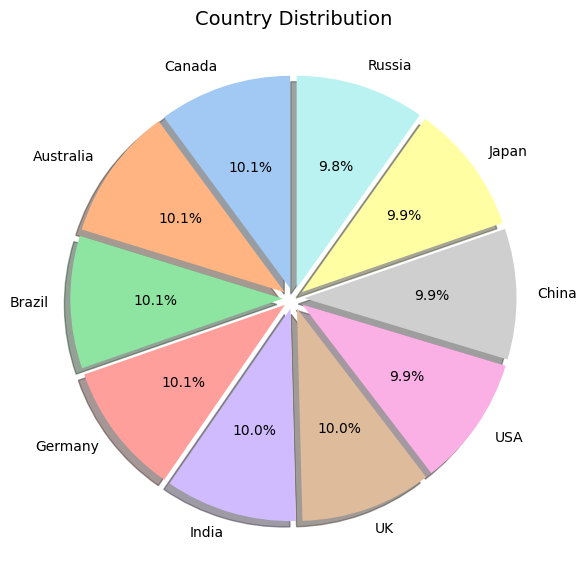

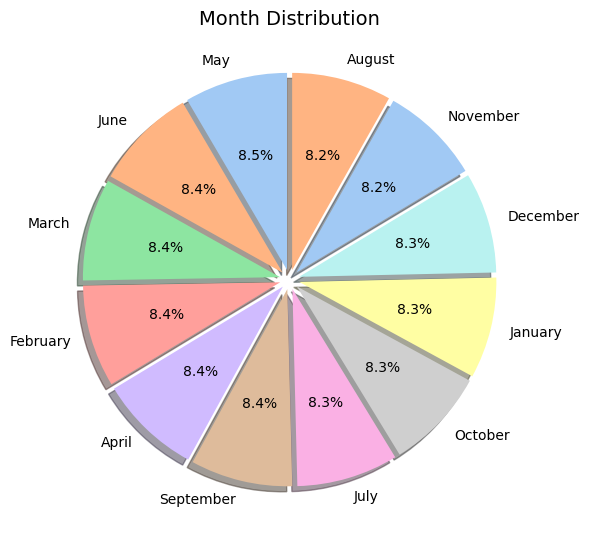

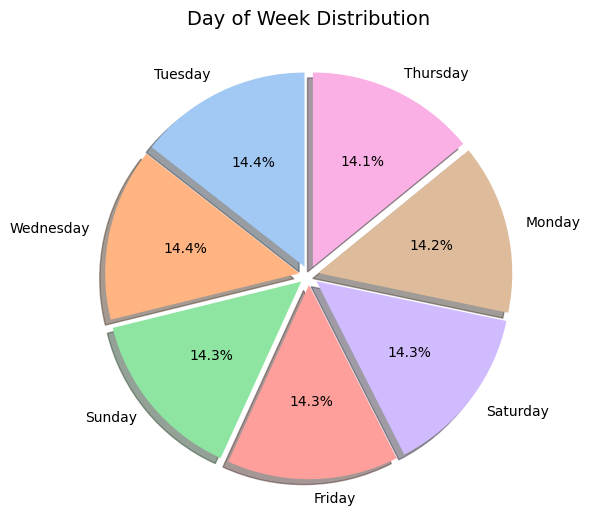

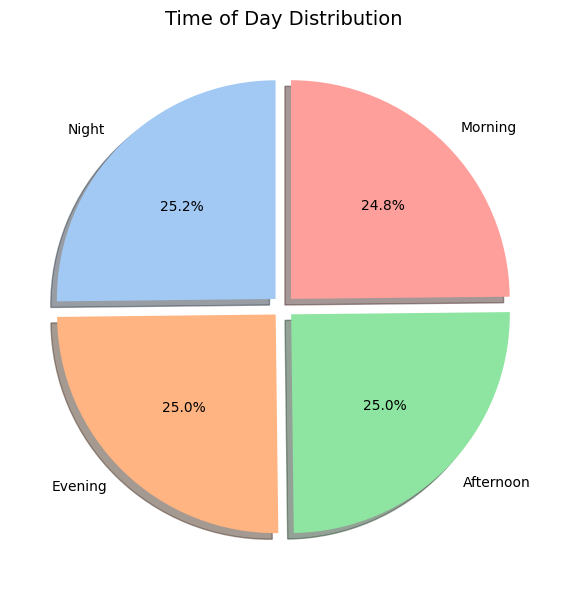

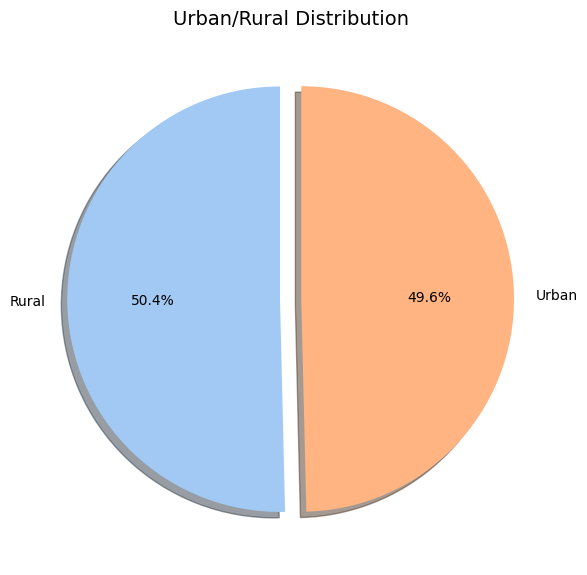

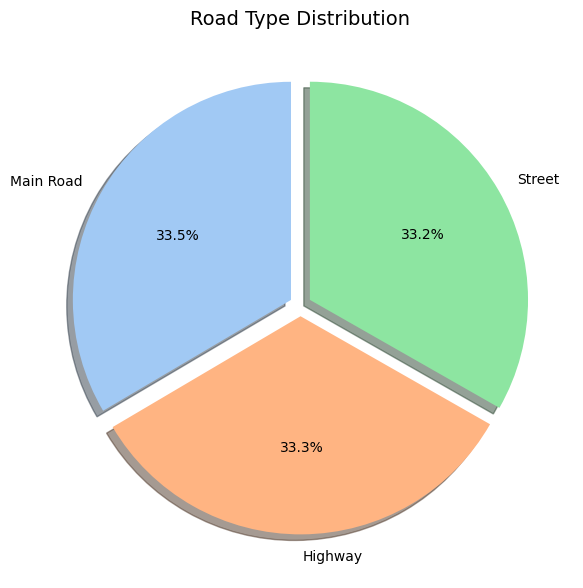

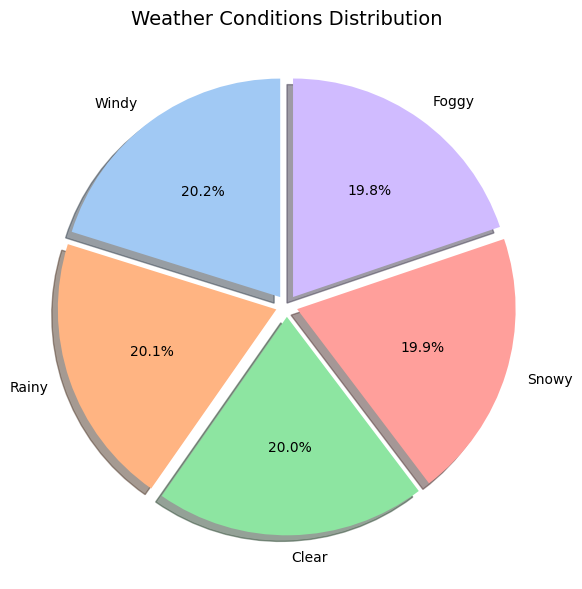

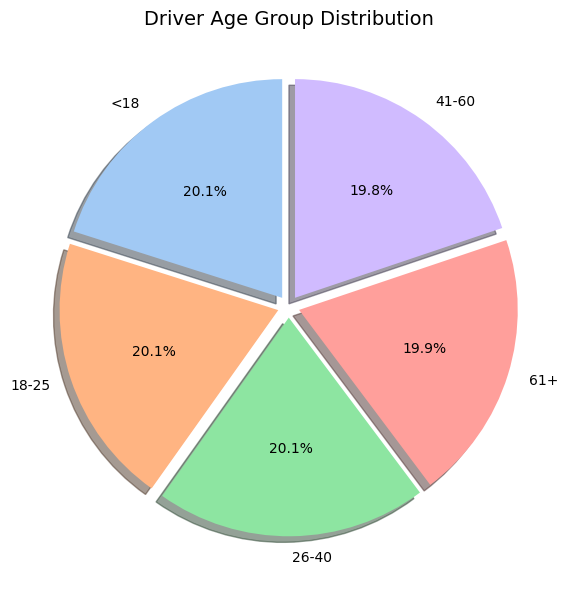

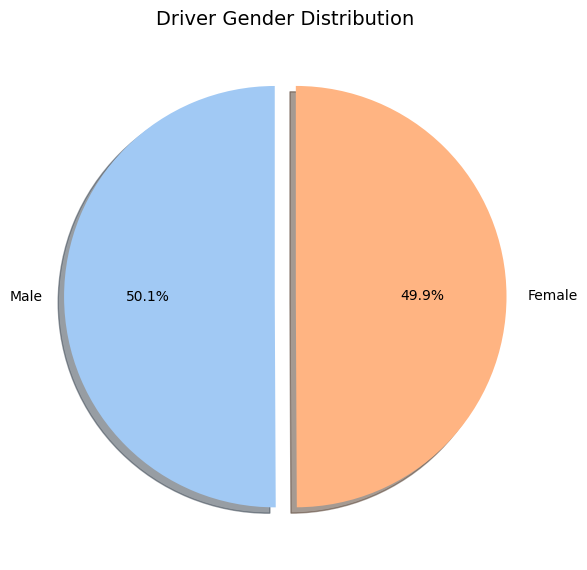

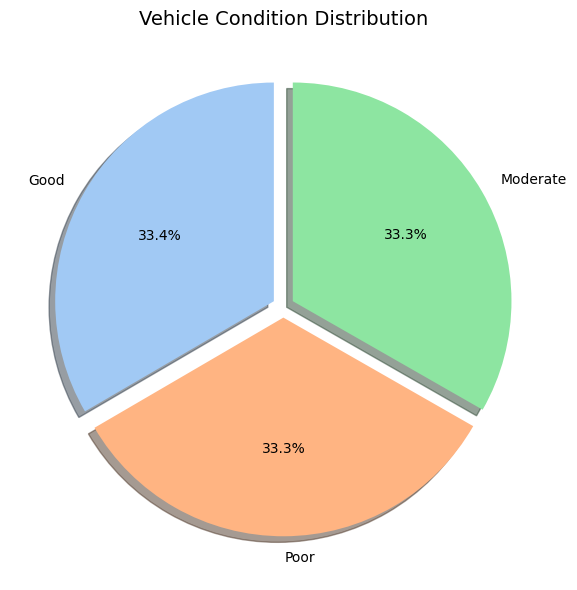

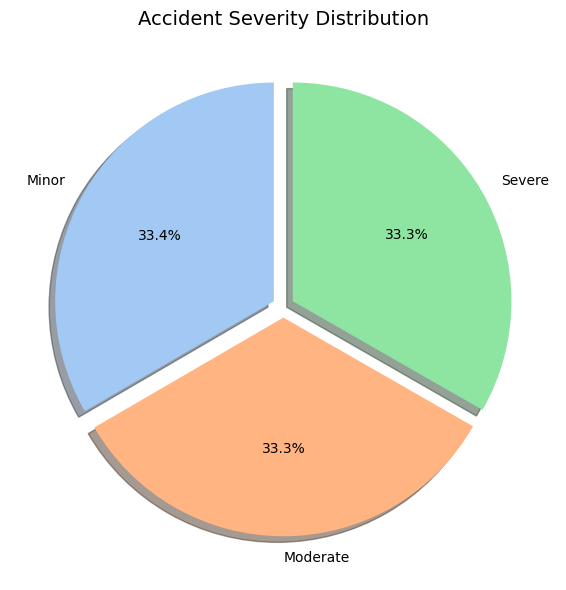

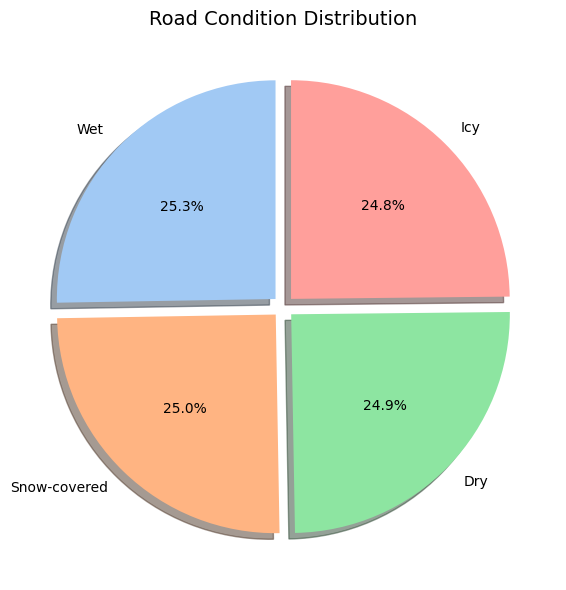

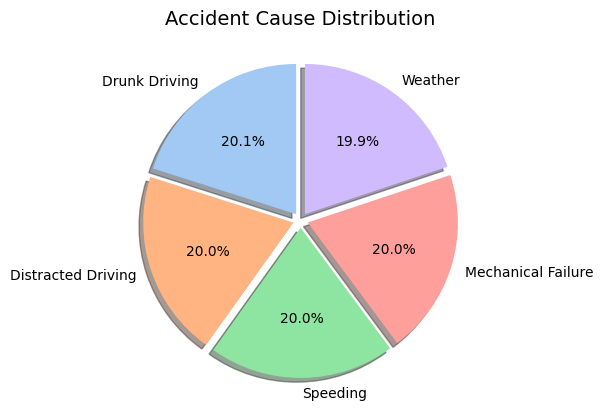

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

cat_cols = data_cleaned.select_dtypes(include=['object', 'category']).columns

# Use a seaborn color palette
colors = sns.color_palette("pastel")  # soft pastel colors

for col in cat_cols:
    counts = data_cleaned[col].value_counts()
    
    # Explode: one value per category
    explode = [0.05] * len(counts)
    
    plt.figure(figsize=(6,6))
    plt.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors[:len(counts)],  # adjust colors to number of categories
        shadow=True,
        explode=explode
    )
    plt.title(f'{col} Distribution', fontsize=14)
    plt.tight_layout()
    plt.show()


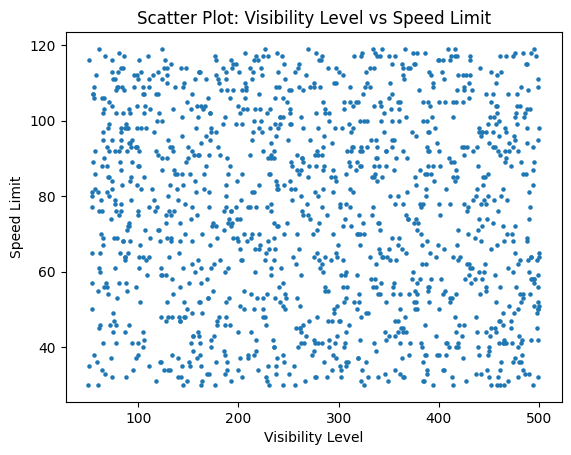

In [125]:
import matplotlib.pyplot as plt
sample = data_cleaned.sample(frac=0.01, random_state=42)
plt.scatter(sample['Visibility Level'], sample['Speed Limit'],s=5)
plt.xlabel('Visibility Level')
plt.ylabel('Speed Limit')
plt.title('Scatter Plot: Visibility Level vs Speed Limit')
plt.show()


In [81]:
from sklearn.preprocessing import StandardScaler

# Select only numeric columns
numeric_cols = data_cleaned.select_dtypes(include=['int64', 'float64']).columns

# Standardize numerical features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_cleaned[numeric_cols])

#Convert back to DataFrame for easier handling
scaled_data_df = pd.DataFrame(scaled_data, columns=numeric_cols)
scaled_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132000 entries, 0 to 131999
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Visibility Level      132000 non-null  float64
 1   Speed Limit           132000 non-null  float64
 2   Driver Alcohol Level  132000 non-null  float64
 3   Traffic Volume        132000 non-null  float64
 4   Population Density    132000 non-null  float64
dtypes: float64(5)
memory usage: 5.0 MB


In [133]:
print(data_cleaned[numeric_cols].describe())


       Visibility Level    Speed Limit  Driver Alcohol Level  Traffic Volume  \
count     132000.000000  132000.000000         132000.000000   132000.000000   
mean         275.038776      74.544068              0.125232     5041.929098   
std          129.923625      26.001448              0.072225     2860.671611   
min           50.001928      30.000000              0.000002      100.062626   
25%          162.338860      52.000000              0.062630     2560.601299   
50%          274.672990      74.000000              0.125468     5037.909855   
75%          388.014111      97.000000              0.187876     7524.638162   
max          499.999646     119.000000              0.249999     9999.997468   

       Population Density  
count       132000.000000  
mean          2506.476223  
std           1440.646352  
min             10.002669  
25%           1258.158299  
50%           2506.203333  
75%           3756.652950  
max           4999.991745  


In [ ]:
from sklearn.decomposition import PCA

# Perform PCA 
pca = PCA(n_components=0.95) # Retain 95% variance
pca_data = pca.fit_transform(scaled_data_df)

# Convert PCA output to DataFrame
pca_df = pd.DataFrame(pca_data)
print("Number of PCA components:", pca.n_components_)


Number of PCA components: 5


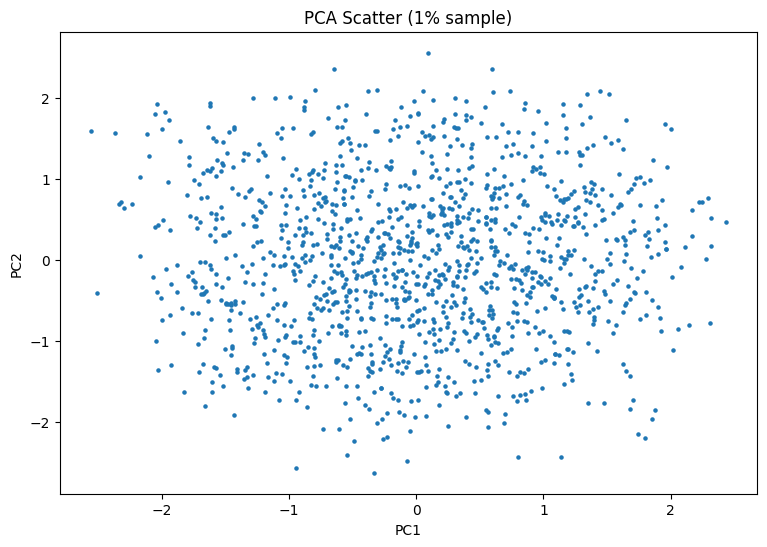

In [126]:
sample_size = int(0.01 * pca_data.shape[0])
sample_idx = np.random.choice(pca_data.shape[0], size=sample_size, replace=False)
sample = pca_data[sample_idx]

plt.figure(figsize=(9, 6))
plt.scatter(sample[:, 0], sample[:, 1], s=5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Scatter (1% sample)')
plt.show()

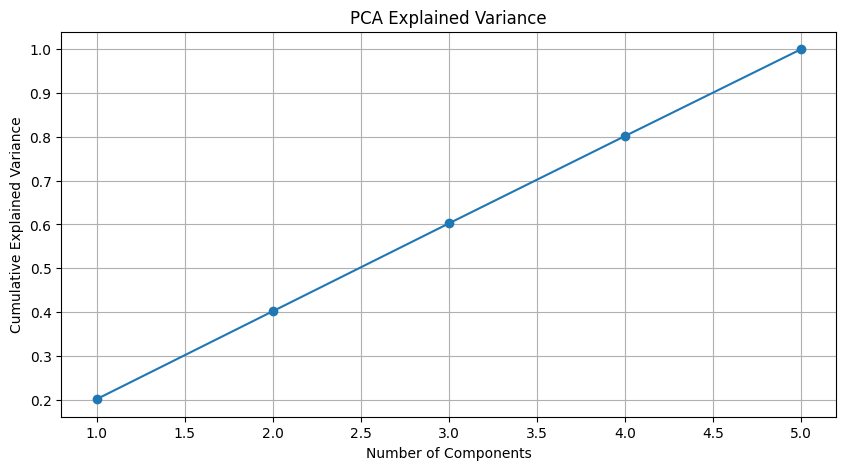

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_.cumsum(),
         marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()


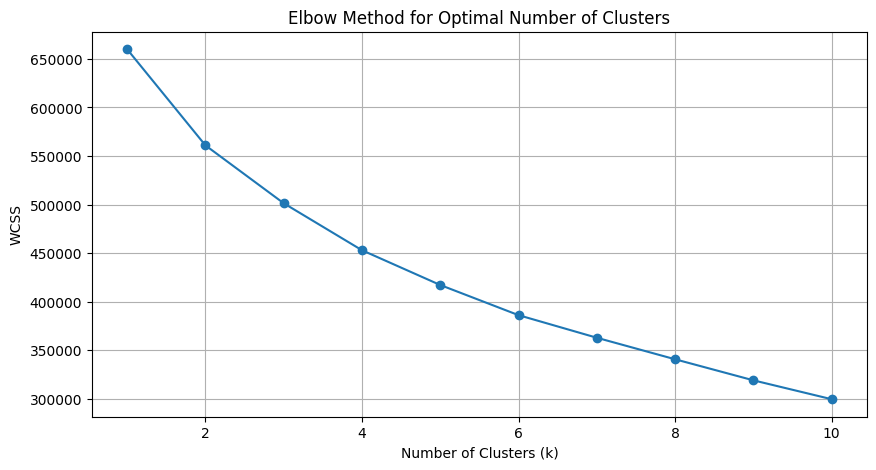

In [118]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
K = range(1, 11) 

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pca_df)
    wcss.append(kmeans.inertia_)  # inertia_ = WCSS

# Plot WCSS
plt.figure(figsize=(10,5))
plt.plot(K, wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.grid(True)
plt.show()


In [127]:
#Elbow detection using Kneedle
from kneed import KneeLocator

kl = KneeLocator(K, wcss, curve="convex", direction="decreasing")
optimal_k = kl.elbow
print("Optimal number of clusters (elbow point):", optimal_k)

Optimal number of clusters (elbow point): 4


In [120]:
from sklearn.cluster import KMeans

# Initialize KMeans with optimal k
kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(pca_df)

# Add cluster labels to original cleaned dataset
data_cleaned['Cluster'] = cluster_labels

# Check number of points per cluster
print(data_cleaned['Cluster'].value_counts())


Cluster
0    33105
2    33021
3    32976
1    32898
Name: count, dtype: int64


In [60]:
centroids = kmeans.cluster_centers_
print("Cluster centroids (PCA space):\n", centroids)


Cluster centroids (PCA space):
 [[-0.76786768  0.23730555  0.37069827 -0.77683137 -0.41936535]
 [ 0.75663892 -0.75855629 -0.36493211  0.01836719 -0.54574434]
 [-0.54049427 -0.20206719 -0.31820083  1.04267327  0.21516156]
 [ 0.55740627  0.72006534  0.31028902 -0.28276926  0.7490965 ]]


In [61]:
original_centroids = pca.inverse_transform(centroids)
original_centroids_df = pd.DataFrame(original_centroids, columns=numeric_cols)
print(original_centroids_df)


   Visibility Level  Speed Limit  Driver Alcohol Level  Traffic Volume  \
0         -0.012664    -0.807783             -0.952652        0.003136   
1         -0.003071     0.824396              0.065781       -0.009761   
2         -0.003410     0.809929             -0.052837        0.009850   
3          0.019177    -0.821882              0.943001       -0.003280   

   Population Density  
0            0.049570  
1            0.946150  
2           -0.953307  
3           -0.038204  


C:\Users\ACER NITRO\AppData\Local\Temp\ipykernel_23500\4234832531.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="Set2")


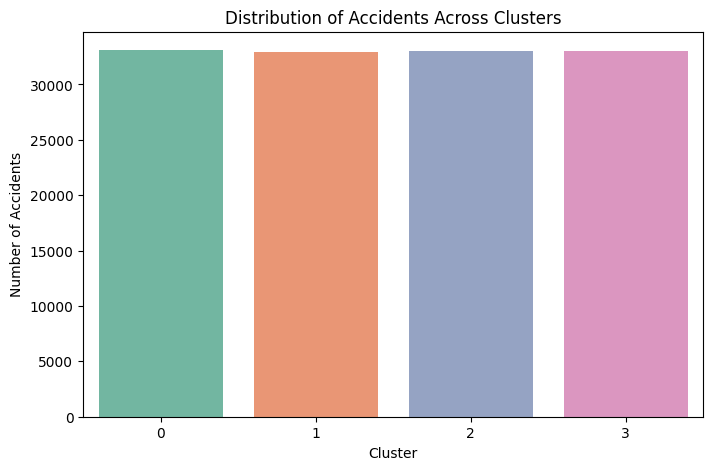

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count number of accidents in each cluster
cluster_counts = data_cleaned['Cluster'].value_counts().sort_index()

# Plot bar chart
plt.figure(figsize=(8,5))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="Set2")
plt.xlabel("Cluster")
plt.ylabel("Number of Accidents")
plt.title("Distribution of Accidents Across Clusters")
plt.show()


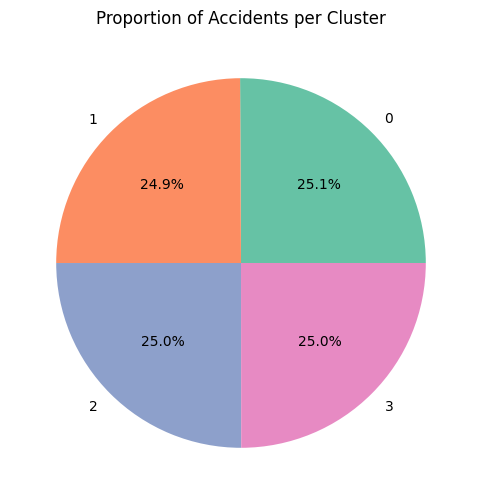

In [122]:
plt.figure(figsize=(6,6))
plt.pie(cluster_counts.values, labels=cluster_counts.index, autopct='%1.1f%%', colors=sns.color_palette("Set2"))
plt.title("Proportion of Accidents per Cluster")
plt.show()


In [20]:
# Make sure 'Cluster' column is added to original cleaned data
cluster_profile_orig = data_cleaned.groupby('Cluster')[[
    'Visibility Level', 'Speed Limit', 'Driver Alcohol Level', 
    'Driver Fatigue', 'Traffic Volume', 'Population Density'
]].mean()


In [23]:
# Step 1: Inverse PCA transform to get scaled feature centroids
centroids_scaled = pca.inverse_transform(centroids)  # back to standardized scale

# Step 2: Inverse StandardScaler transform to get original feature scale
centroids_orig = scaler.inverse_transform(centroids_scaled)

import pandas as pd
centroids_df = pd.DataFrame(centroids_orig, columns=numeric_cols)
print(centroids_df)


   Visibility Level  Speed Limit  Driver Alcohol Level  Driver Fatigue  \
0        277.283431    74.822863              0.126125    3.330669e-16   
1        272.240576    74.318106              0.124340   -4.440892e-16   
2        276.255980    74.871186              0.187784    1.000000e+00   
3        274.374319    74.163280              0.062436    1.000000e+00   

   Traffic Volume  Population Density  
0     5055.675780         3751.090376  
1     5046.927836         1253.786991  
2     5089.497577         2530.220058  
3     4975.444529         2492.757216  


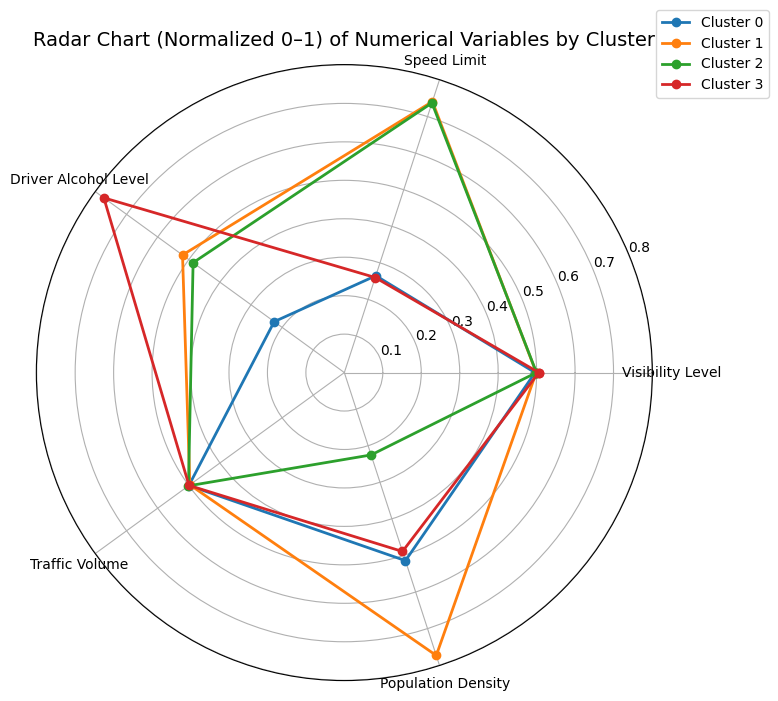

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Numerical variables
num_vars = [
    'Visibility Level',
    'Speed Limit',
    'Driver Alcohol Level',
    'Traffic Volume',
    'Population Density'
]

# Scale 0–1
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data_cleaned[num_vars])

scaled_df = pd.DataFrame(scaled, columns=num_vars)
scaled_df['Cluster'] = data_cleaned['Cluster']

# Mean for radar
cluster_means = scaled_df.groupby('Cluster')[num_vars].mean()

# Radar setup
N = len(num_vars)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(10, 8))

for cluster in cluster_means.index:
    values = cluster_means.loc[cluster].tolist()
    values += values[:1]
    plt.polar(angles, values, marker='o', linewidth=2, label=f"Cluster {cluster}")

plt.xticks(angles[:-1], num_vars)
plt.title("Radar Chart (Normalized 0–1) of Numerical Variables by Cluster", fontsize=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))

plt.show()


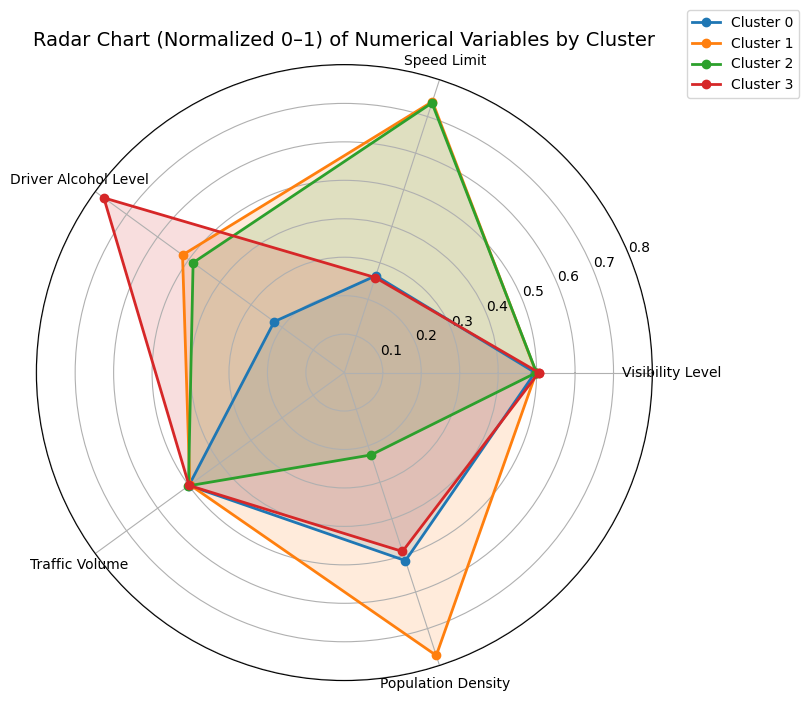

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Numerical variables
num_vars = [
    'Visibility Level',
    'Speed Limit',
    'Driver Alcohol Level',
    'Traffic Volume',
    'Population Density'
]

# Scale 0–1
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data_cleaned[num_vars])

scaled_df = pd.DataFrame(scaled, columns=num_vars)
scaled_df['Cluster'] = data_cleaned['Cluster']

# Mean for radar
cluster_means = scaled_df.groupby('Cluster')[num_vars].mean()

# Radar setup
N = len(num_vars)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(10, 8))

for cluster in cluster_means.index:
    values = cluster_means.loc[cluster].tolist()
    values += values[:1]
    
    # Plot line
    plt.polar(angles, values, marker='o', linewidth=2, label=f"Cluster {cluster}")
    
    # Fill shade
    plt.fill(angles, values, alpha=0.15)   # light shading

plt.xticks(angles[:-1], num_vars)
plt.title("Radar Chart (Normalized 0–1) of Numerical Variables by Cluster", fontsize=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))

plt.show()


In [114]:
cluster_means.min(), cluster_means.max()



(Visibility Level        0.430679
 Speed Limit             0.311797
 Driver Alcohol Level    0.256636
 Traffic Volume          0.301335
 Population Density      0.310147
 dtype: float64,
 Visibility Level        0.571230
 Speed Limit             0.689386
 Driver Alcohol Level    0.744751
 Traffic Volume          0.697362
 Population Density      0.689868
 dtype: float64)

C:\Users\ACER NITRO\AppData\Local\Temp\ipykernel_23500\676829422.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.05))


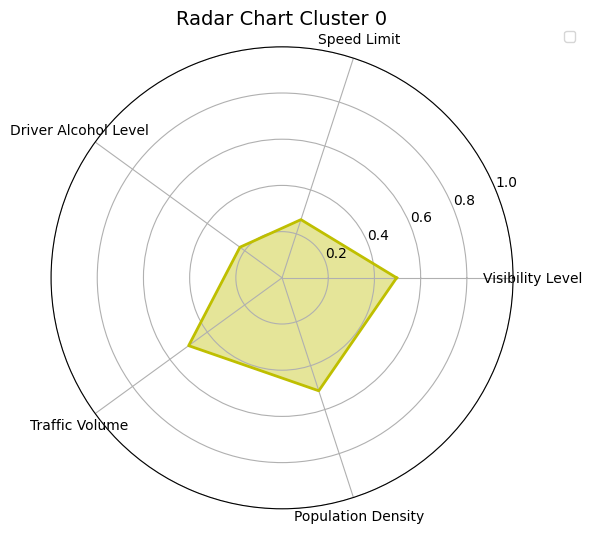

C:\Users\ACER NITRO\AppData\Local\Temp\ipykernel_23500\676829422.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.05))


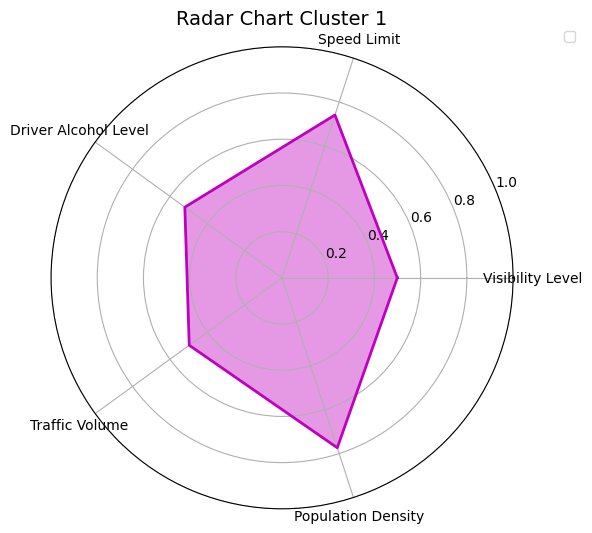

C:\Users\ACER NITRO\AppData\Local\Temp\ipykernel_23500\676829422.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.05))


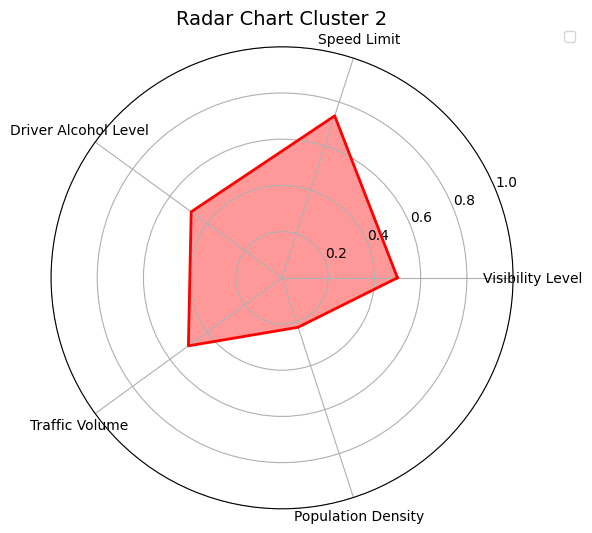

C:\Users\ACER NITRO\AppData\Local\Temp\ipykernel_23500\676829422.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.05))


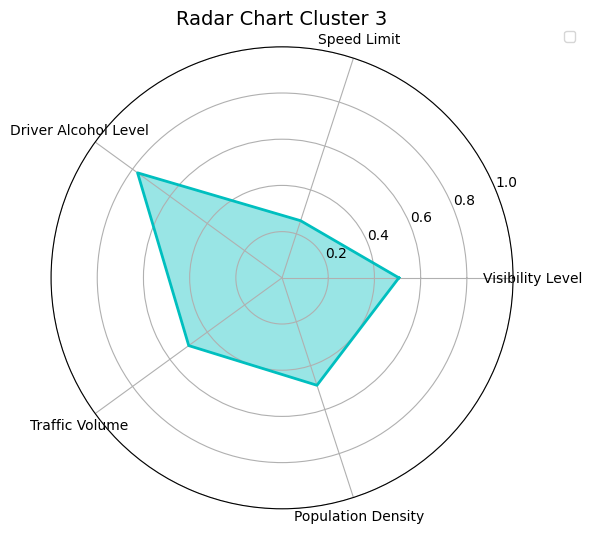

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Numerical variables
num_vars = [
    'Visibility Level',
    'Speed Limit',
    'Driver Alcohol Level',
    'Traffic Volume',
    'Population Density'
]

# Scale 0–1
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data_cleaned[num_vars])

scaled_df = pd.DataFrame(scaled, columns=num_vars)
scaled_df['Cluster'] = data_cleaned['Cluster']

# Mean for radar
cluster_means = scaled_df.groupby('Cluster')[num_vars].mean()

# Radar setup
N = len(num_vars)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close loop

# Radial ticks
radial_ticks = [0.2, 0.4,  0.6,  0.8,1.0]
colors = ['y', 'm', 'r', 'c']  


# Create 1 radar chart per cluster
for cluster in cluster_means.index:
    values = cluster_means.loc[cluster].tolist()
    values += values[:1]

    plt.figure(figsize=(8, 6))
    ax = plt.subplot(111, polar=True)

    # Set radial scale 0.2 to 0.8
    ax.set_ylim(0.0, 1.0)
    ax.set_yticks(radial_ticks)
    ax.set_yticklabels([str(t) for t in radial_ticks])

    # Plot + fill
    color = colors[cluster % len(colors)]  # cycle colors if >6 clusters
    ax.plot(angles, values, linewidth=2, color=color)
    ax.fill(angles, values, color=color, alpha=0.4)  # stronger fill
    #ax.plot(angles, values, linewidth=2,)
    #ax.fill(angles, values, alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(num_vars)

    plt.title(f"Radar Chart Cluster {cluster}", fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.05))

    plt.show()


In [132]:
numeric_cols = [
    "Visibility Level",
    "Speed Limit",
    "Driver Alcohol Level",
    "Traffic Volume",
    "Population Density"
]

cluster_profiles = data_cleaned.groupby("Cluster")[numeric_cols].mean()
print(cluster_profiles)


         Visibility Level  Speed Limit  Driver Alcohol Level  Traffic Volume  \
Cluster                                                                        
0              273.209171    53.571183              0.056347     5047.042566   
1              274.535943    95.953189              0.130049     5016.900972   
2              274.839449    95.620787              0.121542     5060.670232   
3              277.576780    53.135038              0.193276     5042.997841   

         Population Density  
Cluster                      
0               2576.116119  
1               3869.975837  
2               1133.662160  
3               2450.976892  


In [130]:
# Take sample from PCA data
pca_df_sample = pca_df.sample(n=10000, random_state=42)

# Get the corresponding cluster labels
sample_labels = cluster_labels[pca_df_sample.index]

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sil_score = silhouette_score(pca_df_sample, sample_labels)
dbi_score = davies_bouldin_score(pca_df_sample, sample_labels)
ch_score = calinski_harabasz_score(pca_df_sample, sample_labels)

print("Silhouette Score:", sil_score)
print("Davies-Bouldin Index:", dbi_score)
print("Calinski-Harabasz Index:", ch_score)


Silhouette Score: 0.14119783365898747
Davies-Bouldin Index: 1.8940924904996275
Calinski-Harabasz Index: 1527.36386956838


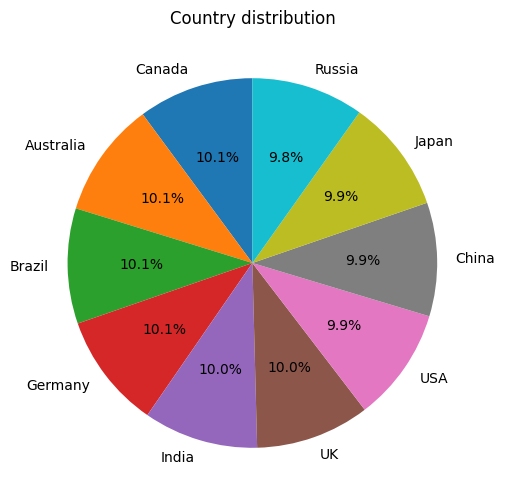

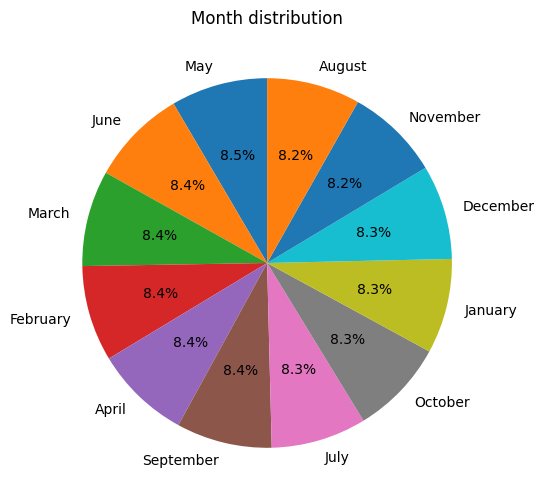

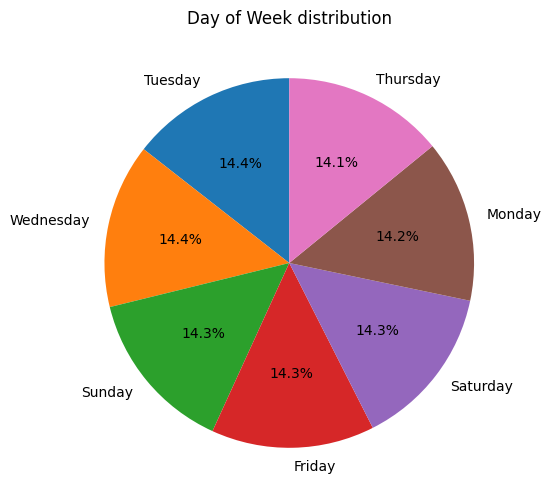

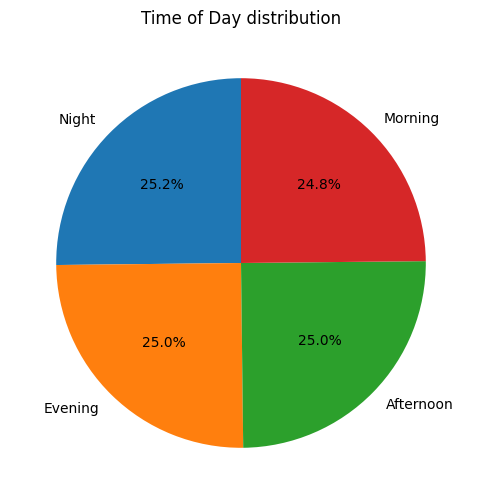

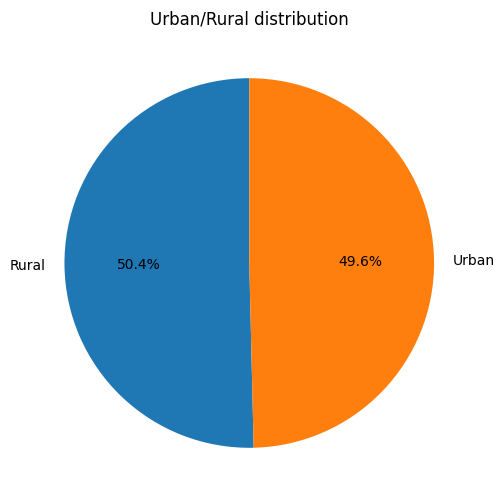

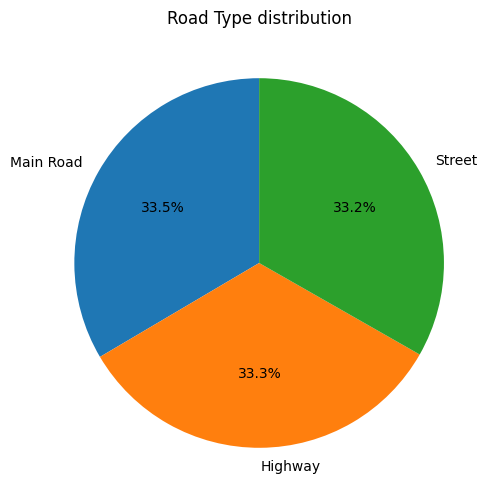

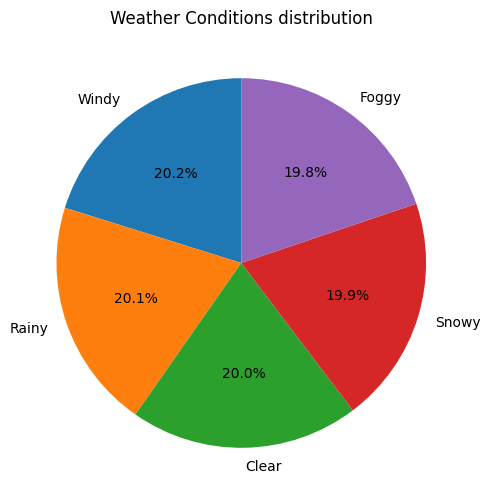

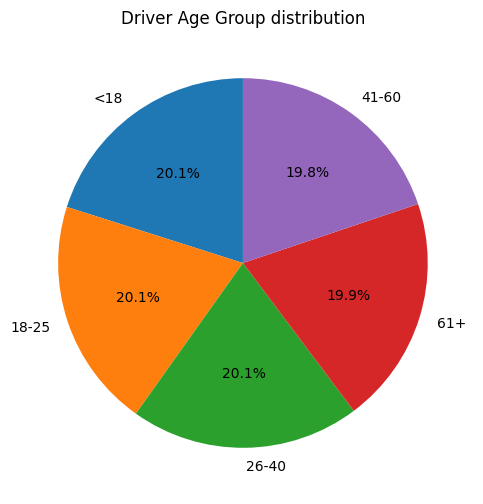

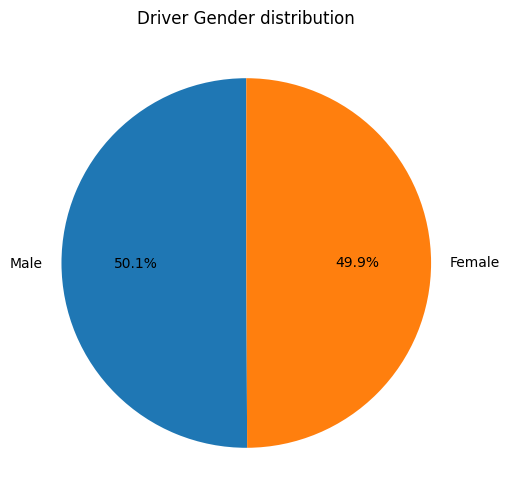

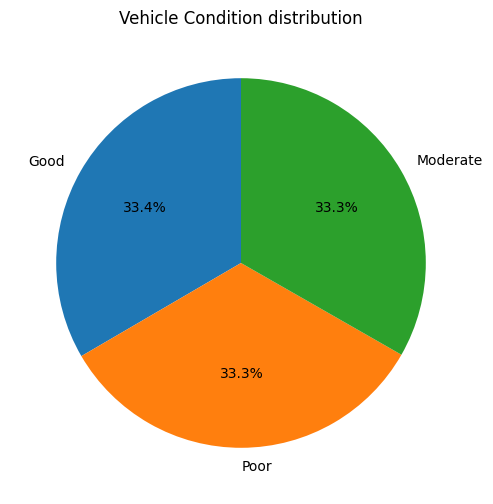

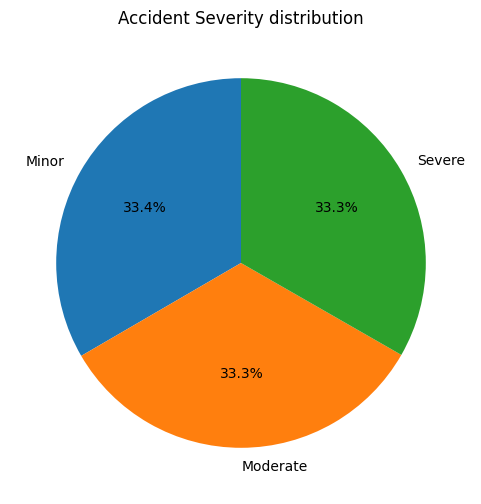

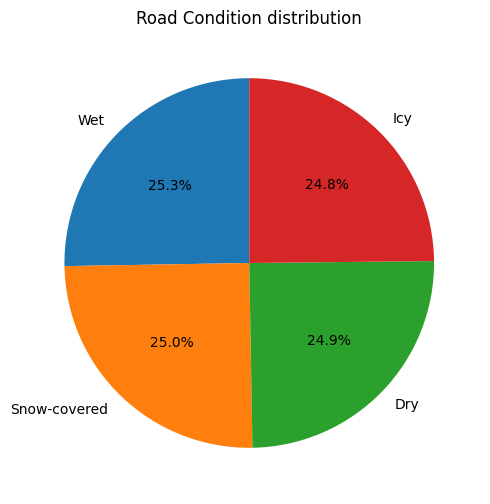

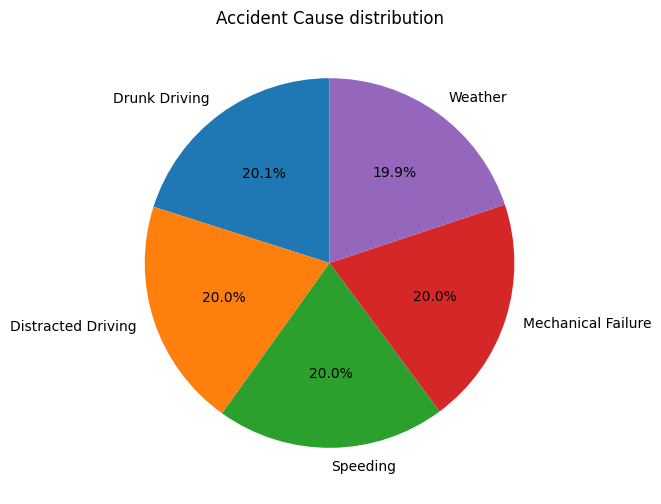

In [ ]:
cat_cols = data_cleaned.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    counts = data_cleaned[col].value_counts()
    plt.figure(figsize=(6,6))
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
    plt.title(f'{col} distribution')
    plt.show()